In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## DATA LOADING AND CLEANING

In [56]:
df = pd.read_csv('day_wise.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [57]:
df.head(5)

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [58]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
183    False
184    False
185    False
186    False
187    False
Length: 188, dtype: bool

In [59]:
df.isnull().sum()

Date                      0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
No. of countries          0
dtype: int64

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    188 non-null    datetime64[ns]
 1   Confirmed               188 non-null    int64         
 2   Deaths                  188 non-null    int64         
 3   Recovered               188 non-null    int64         
 4   Active                  188 non-null    int64         
 5   New cases               188 non-null    int64         
 6   New deaths              188 non-null    int64         
 7   New recovered           188 non-null    int64         
 8   Deaths / 100 Cases      188 non-null    float64       
 9   Recovered / 100 Cases   188 non-null    float64       
 10  Deaths / 100 Recovered  188 non-null    float64       
 11  No. of countries        188 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory 

## EDA

In [61]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
count,1.880000e+02,188.000000,1.880000e+02,1.880000e+02,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,4.406960e+06,230770.760638,2.066001e+06,2.110188e+06,87771.021277,3478.824468,50362.015957,4.860638,34.343936,22.104521,144.351064
std,4.757988e+06,217929.094183,2.627976e+06,1.969670e+06,75295.293255,2537.735652,56090.892479,1.579541,16.206159,22.568307,65.175979
min,5.550000e+02,17.000000,2.800000e+01,5.100000e+02,0.000000,0.000000,0.000000,2.040000,1.710000,6.260000,6.000000
25%,1.121910e+05,3935.000000,6.044125e+04,5.864175e+04,5568.500000,250.750000,2488.250000,3.510000,22.785000,9.650000,101.250000
50%,2.848733e+06,204190.000000,7.847840e+05,1.859759e+06,81114.000000,4116.000000,30991.500000,4.850000,35.680000,15.380000,184.000000
75%,7.422046e+06,418634.500000,3.416396e+06,3.587015e+06,131502.500000,5346.000000,79706.250000,6.297500,48.945000,25.342500,187.000000
max,1.648048e+07,654036.000000,9.468087e+06,6.358362e+06,282756.000000,9966.000000,284394.000000,7.180000,57.450000,134.430000,187.000000


In [62]:
df.corr()

C:\Users\kavis\AppData\Local\Temp\ipykernel_11588\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
Confirmed,1.000000,0.975981,0.990165,0.986543,0.961473,0.555479,0.944875,0.221469,0.720283,-0.400336,0.595890
Deaths,0.975981,1.000000,0.936940,0.996879,0.952450,0.625537,0.923130,0.383897,0.715555,-0.410470,0.683543
Recovered,0.990165,0.936940,1.000000,0.953981,0.936576,0.476217,0.935754,0.096131,0.711328,-0.382937,0.510129
Active,0.986543,0.996879,0.953981,1.000000,0.967578,0.637241,0.931824,0.364250,0.711695,-0.410725,0.683194
New cases,0.961473,0.952450,0.936576,0.967578,1.000000,0.721846,0.928570,0.367629,0.670914,-0.405802,0.722150
New deaths,0.555479,0.625537,0.476217,0.637241,0.721846,1.000000,0.555759,0.774790,0.328203,-0.271905,0.835157
New recovered,0.944875,0.923130,0.935754,0.931824,0.928570,0.555759,1.000000,0.215238,0.684925,-0.383327,0.570745
Deaths / 100 Cases,0.221469,0.383897,0.096131,0.364250,0.367629,0.774790,0.215238,1.000000,0.241877,-0.282469,0.823181
Recovered / 100 Cases,0.720283,0.715555,0.711328,0.711695,0.670914,0.328203,0.684925,0.241877,1.000000,-0.750625,0.581216
Deaths / 100 Recovered,-0.400336,-0.410470,-0.382937,-0.410725,-0.405802,-0.271905,-0.383327,-0.282469,-0.750625,1.000000,-0.502025


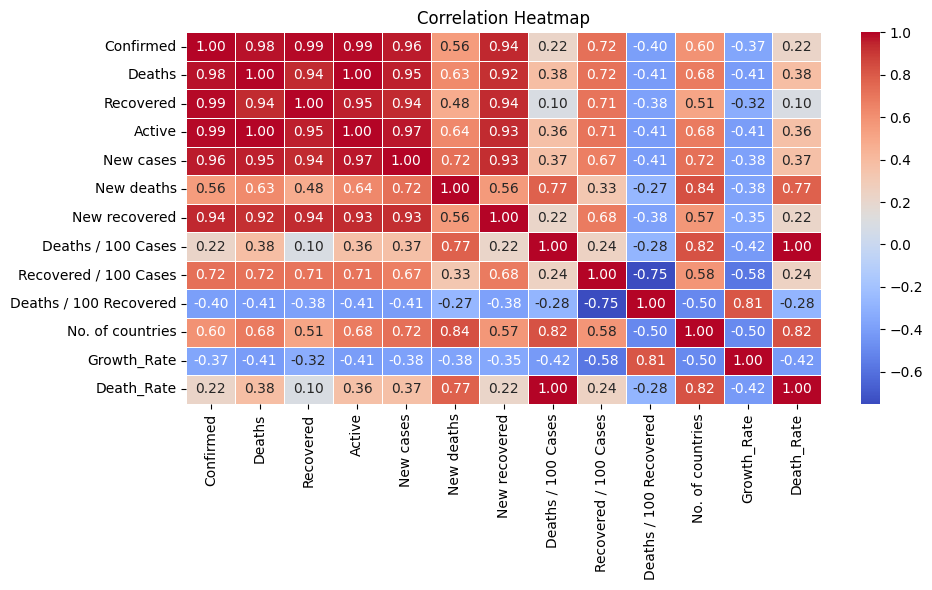

In [69]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,        
            cmap='coolwarm',   
            fmt='.2f',         
            linewidths=0.5)    

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [63]:
deaths = df['Deaths']
active = df['Active']
date = df['Date']

In [64]:
date

0     2020-01-22
1     2020-01-23
2     2020-01-24
3     2020-01-25
4     2020-01-26
         ...    
183   2020-07-23
184   2020-07-24
185   2020-07-25
186   2020-07-26
187   2020-07-27
Name: Date, Length: 188, dtype: datetime64[ns]

In [65]:
df['Growth_Rate'] = df['Confirmed'].pct_change() * 100
df['Death_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

In [67]:
growth_rate = df['Growth_Rate']
death_rate = df['Death_Rate']

In [66]:
df.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries,Growth_Rate,Death_Rate
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6,NaN,3.063063
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8,17.837838,2.752294
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9,43.883792,2.763018
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11,52.391073,2.928870
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13,47.698745,2.644004


## VISUALIZATION

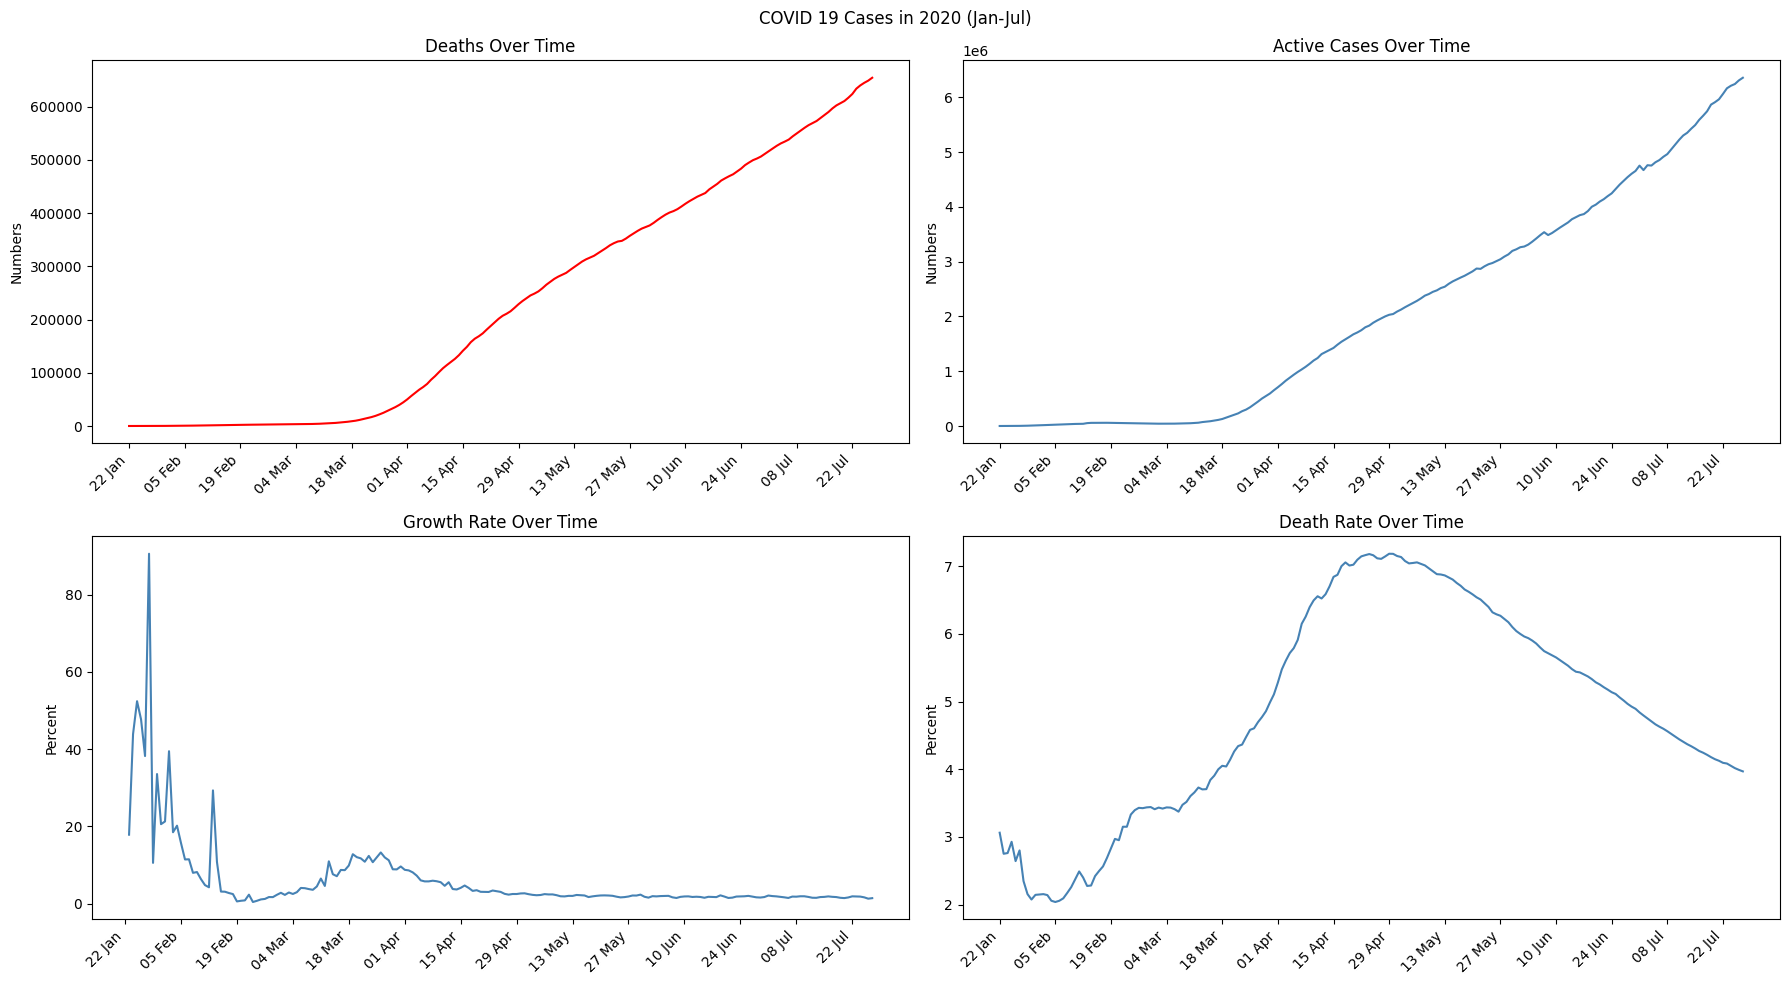

In [68]:



fig, axis = plt.subplots(2, 2, figsize=(18, 10))

plt.suptitle('COVID 19 Cases in 2020 (Jan-Jul)')
step = 14


axis[0, 0].plot(date, deaths, color='red')
axis[0, 0].set_xticks(df['Date'][::step])                                       
axis[0, 0].set_xticklabels(date[::step].dt.strftime('%d %b'), rotation=45, ha='right') 
axis[0, 0].set_ylabel('Numbers')                                                
axis[0, 0].set_title('Deaths Over Time')


axis[0,1].plot(date, active, color='steelblue')
axis[0,1].set_xticks(df['Date'][::step])                                       
axis[0,1].set_xticklabels(date[::step].dt.strftime('%d %b'), rotation=45, ha='right')  
axis[0,1].set_ylabel('Numbers')
axis[0,1].set_title('Active Cases Over Time')

axis[1,0].plot(date, growth_rate, color='steelblue')
axis[1,0].set_xticks(df['Date'][::step])                                       
axis[1,0].set_xticklabels(date[::step].dt.strftime('%d %b'), rotation=45, ha='right')  
axis[1,0].set_ylabel('Percent')
axis[1,0].set_title('Growth Rate Over Time')

axis[1,1].plot(date, death_rate, color='steelblue')
axis[1,1].set_xticks(df['Date'][::step])                                       
axis[1,1].set_xticklabels(date[::step].dt.strftime('%d %b'), rotation=45, ha='right')  
axis[1,1].set_ylabel('Percent')
axis[1,1].set_title('Death Rate Over Time')

plt.tight_layout()
plt.show()


## INSIGHTS AND CONCLUSION 
Cases grew exponentially between March and April 2020 as the virus spread globally.
Death rate peaked at around 7% in mid-April 2020 and gradually declined as healthcare improved.
Recovery rate steadily improved from under 5% in January to over 50% by July 2020.
Growth rate was highest in early March when the pandemic was declared global.
By July 2020 the pandemic had spread to 187 countries worldwide.
